# Meeting Notes Cleaner — Model Analysis & Visualizations

**Project:** [github.com/vijay0320/meeting-notes-cleaner](https://github.com/vijay0320/meeting-notes-cleaner)  
**Model:** [sunny0320/meeting-notes-cleaner-v3](https://huggingface.co/sunny0320/meeting-notes-cleaner-v3)  
**Author:** Vijay Aditya

This notebook covers:
1. Training data analysis
2. Model training progression (v1 → v3)
3. Priority classification benchmark
4. Smart pipeline — messiness detection
5. Live inference examples

In [1]:
# Install dependencies
!pip install transformers torch rouge-score scikit-learn matplotlib seaborn pandas -q

  Preparing metadata (setup.py) ... done


In [2]:
from google.colab import files
uploaded = files.upload()

Saving aug_train.json to aug_train.json
Saving aug_val.json to aug_val.json
Saving aug_test.json to aug_test.json
Saving aug_train_v2.json to aug_train_v2.json
Saving aug_val_v2.json to aug_val_v2.json
Saving aug_test_v2.json to aug_test_v2.json
Saving ami_test.json to ami_test.json


In [3]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import re
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.facecolor'] = '#0d1117'
plt.rcParams['axes.facecolor'] = '#161b22'
plt.rcParams['axes.edgecolor'] = '#30363d'
plt.rcParams['text.color'] = '#e6edf3'
plt.rcParams['axes.labelcolor'] = '#e6edf3'
plt.rcParams['xtick.color'] = '#e6edf3'
plt.rcParams['ytick.color'] = '#e6edf3'
plt.rcParams['grid.color'] = '#21262d'
plt.rcParams['font.family'] = 'monospace'

COLORS = {'high': '#ff6b6b', 'medium': '#ffd93d', 'low': '#6bcb77', 'accent': '#c9d1d9'}
print('Setup complete!')

Setup complete!


## 1. Training Data Analysis

In [4]:
# Load all dataset versions
train_v1 = json.load(open('aug_train.json'))
val_v1 = json.load(open('aug_val.json'))
test_v1 = json.load(open('aug_test.json'))

train_v2 = json.load(open('aug_train_v2.json'))
val_v2 = json.load(open('aug_val_v2.json'))
test_v2 = json.load(open('aug_test_v2.json'))

print(f'Dataset v1 (flan-t5-small): Train={len(train_v1)}, Val={len(val_v1)}, Test={len(test_v1)}, Total={len(train_v1)+len(val_v1)+len(test_v1)}')
print(f'Dataset v2 (flan-t5-base):  Train={len(train_v2)}, Val={len(val_v2)}, Test={len(test_v2)}, Total={len(train_v2)+len(val_v2)+len(test_v2)}')

Dataset v1 (flan-t5-small): Train=357, Val=42, Test=15, Total=414
Dataset v2 (flan-t5-base):  Train=1237, Val=155, Test=155, Total=1547


In [6]:
import os
os.makedirs('assets', exist_ok=True)
print('Assets folder created!')

Assets folder created!


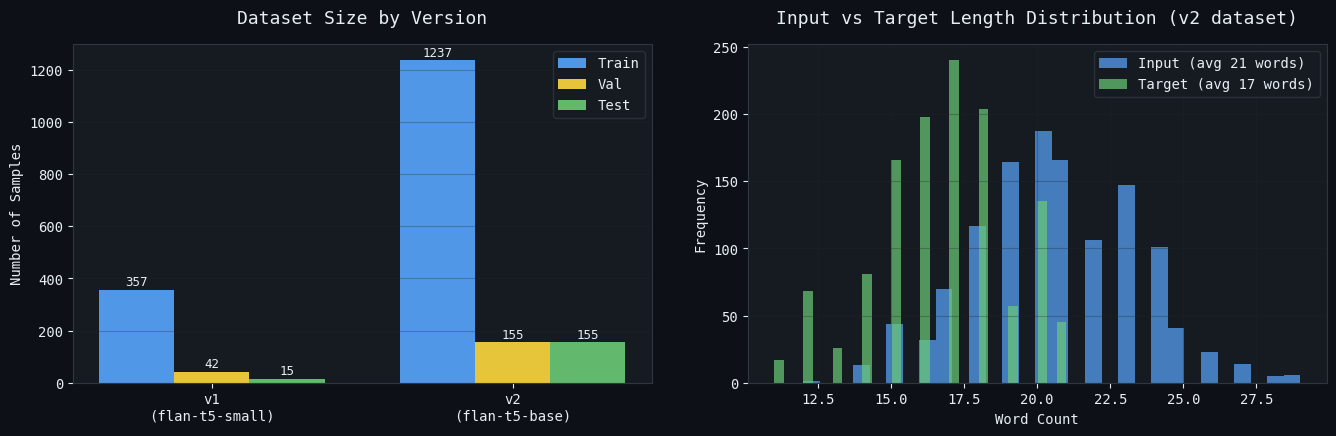

Saved: assets/viz_dataset.png


In [7]:
# Dataset growth visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')

# Dataset size comparison
ax1 = axes[0]
versions = ['v1\n(flan-t5-small)', 'v2\n(flan-t5-base)']
train_sizes = [len(train_v1), len(train_v2)]
val_sizes = [len(val_v1), len(val_v2)]
test_sizes = [len(test_v1), len(test_v2)]

x = np.arange(len(versions))
width = 0.25
ax1.bar(x - width, train_sizes, width, label='Train', color='#58a6ff', alpha=0.9)
ax1.bar(x, val_sizes, width, label='Val', color='#ffd93d', alpha=0.9)
ax1.bar(x + width, test_sizes, width, label='Test', color='#6bcb77', alpha=0.9)
ax1.set_xticks(x)
ax1.set_xticklabels(versions)
ax1.set_title('Dataset Size by Version', color='#e6edf3', pad=15, fontsize=13)
ax1.set_ylabel('Number of Samples', color='#e6edf3')
ax1.legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='#e6edf3')
ax1.grid(axis='y', alpha=0.3)
for bar in ax1.patches:
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(int(bar.get_height())), ha='center', va='bottom', fontsize=9, color='#e6edf3')

# Input/target length distribution
ax2 = axes[1]
input_lens = [len(d['input'].split()) for d in train_v2]
target_lens = [len(d['target'].split()) for d in train_v2]
ax2.hist(input_lens, bins=30, alpha=0.7, color='#58a6ff', label=f'Input (avg {np.mean(input_lens):.0f} words)')
ax2.hist(target_lens, bins=30, alpha=0.7, color='#6bcb77', label=f'Target (avg {np.mean(target_lens):.0f} words)')
ax2.set_title('Input vs Target Length Distribution (v2 dataset)', color='#e6edf3', pad=15, fontsize=13)
ax2.set_xlabel('Word Count', color='#e6edf3')
ax2.set_ylabel('Frequency', color='#e6edf3')
ax2.legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='#e6edf3')
ax2.grid(alpha=0.3)

plt.tight_layout(pad=3)
plt.savefig('assets/viz_dataset.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: assets/viz_dataset.png')

## 2. Model Training Progression (v1 → v3)

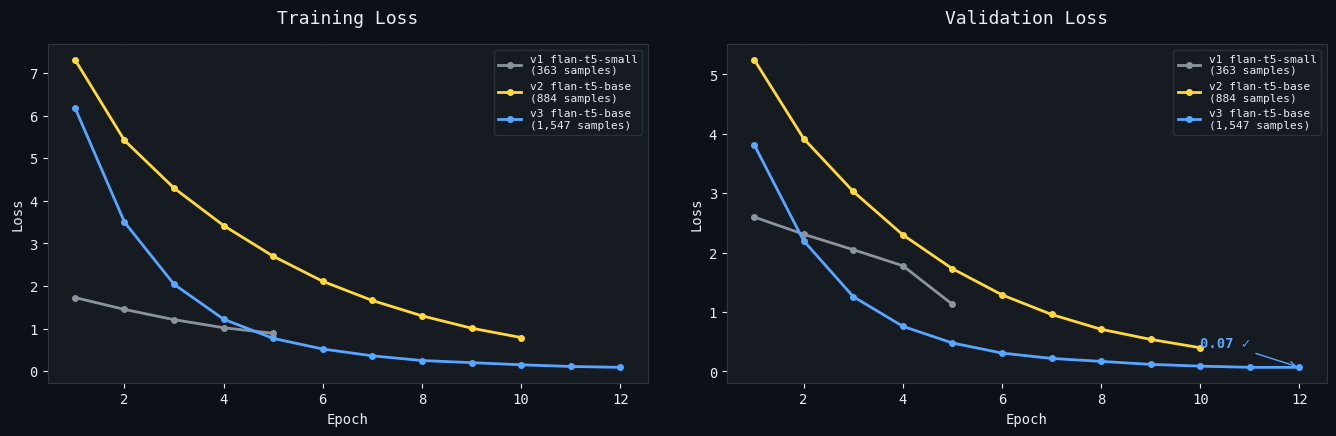

Saved: assets/viz_training.png


In [8]:
# Training history across all versions
training_history = {
    'v1 flan-t5-small\n(363 samples)': {
        'train': [1.73, 1.45, 1.21, 1.02, 0.89],
        'val':   [2.60, 2.31, 2.05, 1.78, 1.13],
        'color': '#8b949e'
    },
    'v2 flan-t5-base\n(884 samples)': {
        'train': [7.32, 5.42, 4.30, 3.42, 2.70, 2.11, 1.66, 1.30, 1.01, 0.79],
        'val':   [5.25, 3.92, 3.03, 2.30, 1.73, 1.29, 0.96, 0.71, 0.54, 0.40],
        'color': '#ffd93d'
    },
    'v3 flan-t5-base\n(1,547 samples)': {
        'train': [6.19, 3.50, 2.04, 1.22, 0.77, 0.52, 0.36, 0.25, 0.20, 0.15, 0.11, 0.09],
        'val':   [3.82, 2.20, 1.26, 0.76, 0.48, 0.31, 0.22, 0.17, 0.12, 0.09, 0.07, 0.07],
        'color': '#58a6ff'
    }
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')

for name, data in training_history.items():
    epochs = range(1, len(data['train']) + 1)
    axes[0].plot(epochs, data['train'], color=data['color'], marker='o', markersize=4, linewidth=2, label=name)
    axes[1].plot(epochs, data['val'], color=data['color'], marker='o', markersize=4, linewidth=2, label=name)

for ax, title in zip(axes, ['Training Loss', 'Validation Loss']):
    ax.set_title(title, color='#e6edf3', pad=15, fontsize=13)
    ax.set_xlabel('Epoch', color='#e6edf3')
    ax.set_ylabel('Loss', color='#e6edf3')
    ax.legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='#e6edf3', fontsize=8)
    ax.grid(alpha=0.3)

# Annotate final val loss
axes[1].annotate('0.07 ✓', xy=(12, 0.07), xytext=(10, 0.4),
                arrowprops=dict(arrowstyle='->', color='#58a6ff'),
                color='#58a6ff', fontsize=10, fontweight='bold')

plt.tight_layout(pad=3)
plt.savefig('assets/viz_training.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: assets/viz_training.png')

## 3. Priority Classification Benchmark

In [9]:
from sklearn.metrics import confusion_matrix, classification_report

# Priority engine
HIGH_KEYWORDS = [
    "asap", "urgent", "critical", "blocker", "block", "must", "immediately",
    "deadline", "overdue", "risk", "high priority", "eod", "escalate",
    "broke", "broken", "down", "failing", "at risk", "expires", "renew",
    "crashed", "crash", "outage", "emergency", "hotfix"
]
MEDIUM_KEYWORDS = [
    "should", "need", "review", "follow up", "discuss", "plan", "schedule",
    "decide", "will", "assigned", "pending", "waiting", "needs", "required",
    "sign off", "approval", "investigate", "prepare", "optimize", "update",
    "adjust", "explore", "analysis", "also"
]
LOW_SIGNALS = ["at some point", "eventually", "fun", "nice to have", "whenever", "someday"]

def flag_priority(text):
    t = text.lower()
    if any(k in t for k in LOW_SIGNALS): return 'low'
    if any(k in t for k in HIGH_KEYWORDS): return 'high'
    if any(k in t for k in MEDIUM_KEYWORDS): return 'medium'
    return 'low'

# Load benchmark data
ami_test = json.load(open('ami_test.json'))
aug_test = json.load(open('aug_test_v2.json'))

# Build labeled test set
test_samples = []
for item in aug_test:
    text = item.get('input', '').replace('summarize meeting notes: ', '')
    target = item.get('target', '')
    t_lower = target.lower()
    if any(k in t_lower for k in ['immediately', 'critical', 'asap', 'urgent', 'broken', 'expired', 'crashed']):
        true_label = 'high'
    elif any(k in t_lower for k in ['will', 'needs to', 'should', 'review', 'prepare', 'update']):
        true_label = 'medium'
    else:
        true_label = 'low'
    pred_label = flag_priority(text)
    test_samples.append({'text': text, 'true': true_label, 'pred': pred_label})

df = pd.DataFrame(test_samples)
y_true = df['true'].tolist()
y_pred = df['pred'].tolist()

accuracy = sum(t == p for t, p in zip(y_true, y_pred)) / len(y_true)
print(f'Priority Classification Accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)')
print()
print(classification_report(y_true, y_pred, target_names=['high', 'low', 'medium']))

Priority Classification Accuracy: 0.594 (59.4%)

              precision    recall  f1-score   support

        high       0.48      0.97      0.64        34
         low       0.92      0.17      0.29        64
      medium       0.65      0.84      0.73        57

    accuracy                           0.59       155
   macro avg       0.68      0.66      0.55       155
weighted avg       0.72      0.59      0.53       155



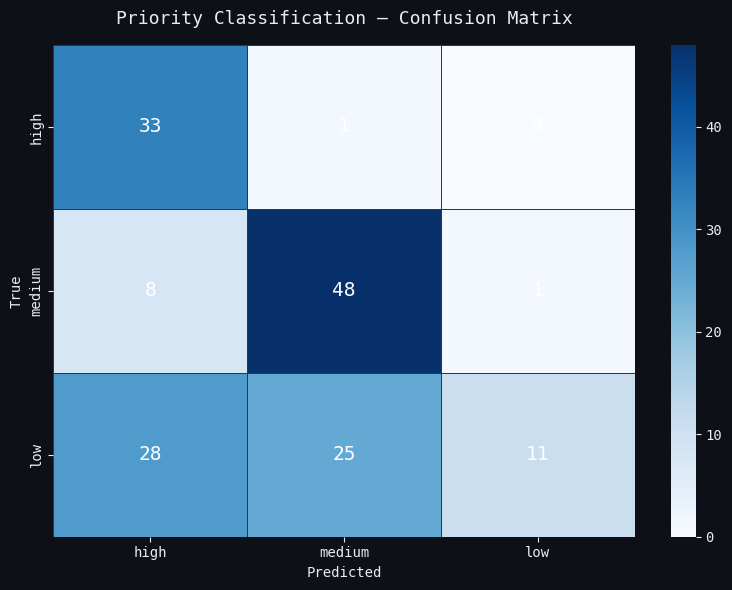

Saved: assets/viz_confusion.png


In [10]:
# Confusion matrix visualization
labels = ['high', 'medium', 'low']
cm = confusion_matrix(y_true, y_pred, labels=labels)

fig, ax = plt.subplots(figsize=(8, 6))
fig.patch.set_facecolor('#0d1117')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            ax=ax, linewidths=0.5, linecolor='#30363d',
            annot_kws={'size': 14, 'color': 'white'})

ax.set_title('Priority Classification — Confusion Matrix', color='#e6edf3', pad=15, fontsize=13)
ax.set_xlabel('Predicted', color='#e6edf3')
ax.set_ylabel('True', color='#e6edf3')
ax.tick_params(colors='#e6edf3')

plt.tight_layout()
plt.savefig('assets/viz_confusion.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: assets/viz_confusion.png')

## 4. Smart Pipeline — Messiness Detection

In [11]:
SHORTHAND = {
    'asap', 'eod', 'b4', 'tmrw', 'lst', 'nite', 'wk', 'pls', 'plz',
    'w/', 'w/o', 'dept', 'mgmt', 'ur', 'thru', 'pct',
    'brken', 'rdy', 'waitng', 'intgration', 'expirng'
}

def is_messy(text):
    words = text.lower().split()
    shorthand_count = sum(1 for w in words if w in SHORTHAND)
    has_number_typo = bool(re.search(r'\d[a-z]|[a-z]\d', text))
    return shorthand_count >= 2 or has_number_typo

def messiness_score(text):
    words = text.lower().split()
    shorthand_count = sum(1 for w in words if w in SHORTHAND)
    has_number_typo = int(bool(re.search(r'\d[a-z]|[a-z]\d', text)))
    return shorthand_count + has_number_typo * 2

# Analyze training data messiness
scores = [messiness_score(d['input'].replace('summarize meeting notes: ', '')) for d in train_v2]
messy_count = sum(1 for d in train_v2 if is_messy(d['input'].replace('summarize meeting notes: ', '')))
clean_count = len(train_v2) - messy_count

print(f'Training data breakdown:')
print(f'  Messy notes (ML cleaning needed): {messy_count} ({messy_count/len(train_v2)*100:.1f}%)')
print(f'  Clean notes (passthrough):        {clean_count} ({clean_count/len(train_v2)*100:.1f}%)')

Training data breakdown:
  Messy notes (ML cleaning needed): 286 (23.1%)
  Clean notes (passthrough):        951 (76.9%)


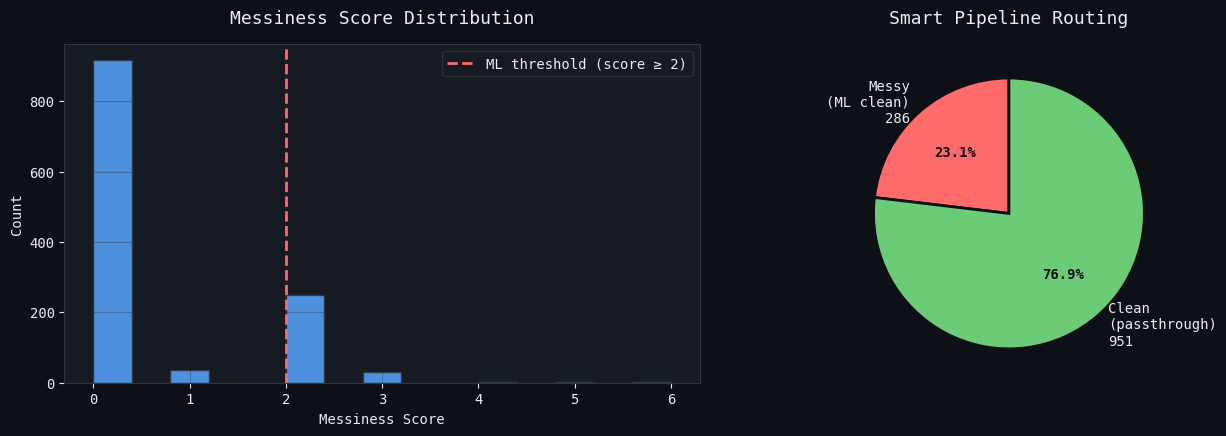

Saved: assets/viz_pipeline.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#0d1117')

# Messiness score distribution
ax1 = axes[0]
ax1.hist(scores, bins=15, color='#58a6ff', alpha=0.85, edgecolor='#30363d')
ax1.axvline(x=2, color='#ff6b6b', linestyle='--', linewidth=2, label='ML threshold (score ≥ 2)')
ax1.set_title('Messiness Score Distribution', color='#e6edf3', pad=15, fontsize=13)
ax1.set_xlabel('Messiness Score', color='#e6edf3')
ax1.set_ylabel('Count', color='#e6edf3')
ax1.legend(facecolor='#161b22', edgecolor='#30363d', labelcolor='#e6edf3')
ax1.grid(alpha=0.3)

# Messy vs clean pie
ax2 = axes[1]
sizes = [messy_count, clean_count]
labels_pie = [f'Messy\n(ML clean)\n{messy_count}', f'Clean\n(passthrough)\n{clean_count}']
colors = ['#ff6b6b', '#6bcb77']
wedges, texts, autotexts = ax2.pie(sizes, labels=labels_pie, colors=colors,
                                    autopct='%1.1f%%', startangle=90,
                                    textprops={'color': '#e6edf3'},
                                    wedgeprops={'edgecolor': '#0d1117', 'linewidth': 2})
for at in autotexts:
    at.set_color('#0d1117')
    at.set_fontweight('bold')
ax2.set_title('Smart Pipeline Routing', color='#e6edf3', pad=15, fontsize=13)

plt.tight_layout(pad=3)
plt.savefig('assets/viz_pipeline.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: assets/viz_pipeline.png')

## 5. Live Inference Examples

In [13]:
import torch
from transformers import T5ForConditionalGeneration, T5Tokenizer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

tokenizer = T5Tokenizer.from_pretrained('sunny0320/meeting-notes-cleaner-v3')
model = T5ForConditionalGeneration.from_pretrained('sunny0320/meeting-notes-cleaner-v3').to(device)
model.eval()
print('Model loaded!')

Device: cpu


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

Model loaded!


In [14]:
def clean_note(text):
    prompt = f'summarize meeting notes: {text}'
    inputs = tokenizer(prompt, return_tensors='pt', max_length=128, truncation=True).to(device)
    with torch.no_grad():
        outputs = model.generate(**inputs, max_new_tokens=64, num_beams=4,
                                  no_repeat_ngram_size=3, early_stopping=True,
                                  repetition_penalty=1.5)
    return tokenizer.decode(outputs[0], skip_special_tokens=True)

# Test examples
examples = [
    ('HIGH', 'api intgration still brken since lst nite deploy cant process any paymnts before mkt opens tmrw critical'),
    ('HIGH', 'ssl cert expirng in 2 days if it goes down whole site dies needs renewl asap'),
    ('HIGH', 'db migration script rdy waitng 4 approval 2 run on prod needs sign off b4 eod'),
    ('MEDIUM', 'q2 infra budget needs cfo approval by fri or we lose the cloud credits'),
    ('MEDIUM', 'new hire still no laptop no access 3rd day someone needs 2 sort this out'),
    ('LOW', 'retro notes frm lst wk still not shared wit the team'),
]

print('=' * 80)
print('LIVE INFERENCE — MESSY NOTES CLEANING')
print('=' * 80)
for priority, note in examples:
    cleaned = clean_note(note)
    print(f'\n[{priority}]')
    print(f'  IN:  {note}')
    print(f'  OUT: {cleaned}')

LIVE INFERENCE — MESSY NOTES CLEANING

[HIGH]
  IN:  api intgration still brken since lst nite deploy cant process any paymnts before mkt opens tmrw critical
  OUT: api integration is broken since last night's deployment. cannot process payments before market opens tomorrow. critical fix needed.

[HIGH]
  IN:  ssl cert expirng in 2 days if it goes down whole site dies needs renewl asap
  OUT: ssl certificate expires in 2 days. if it goes down the entire site goes down. needs renewal immediately.

[HIGH]
  IN:  db migration script rdy waitng 4 approval 2 run on prod needs sign off b4 eod
  OUT: database migration script is ready and waiting for approval to run on production. needs sign off before end of day.

[MEDIUM]
  IN:  q2 infra budget needs cfo approval by fri or we lose the cloud credits
  OUT: q2 infrastructure budget needs cfo approval by friday or the team will lose the cloud credits.

[MEDIUM]
  IN:  new hire still no laptop no access 3rd day someone needs 2 sort this out
  O

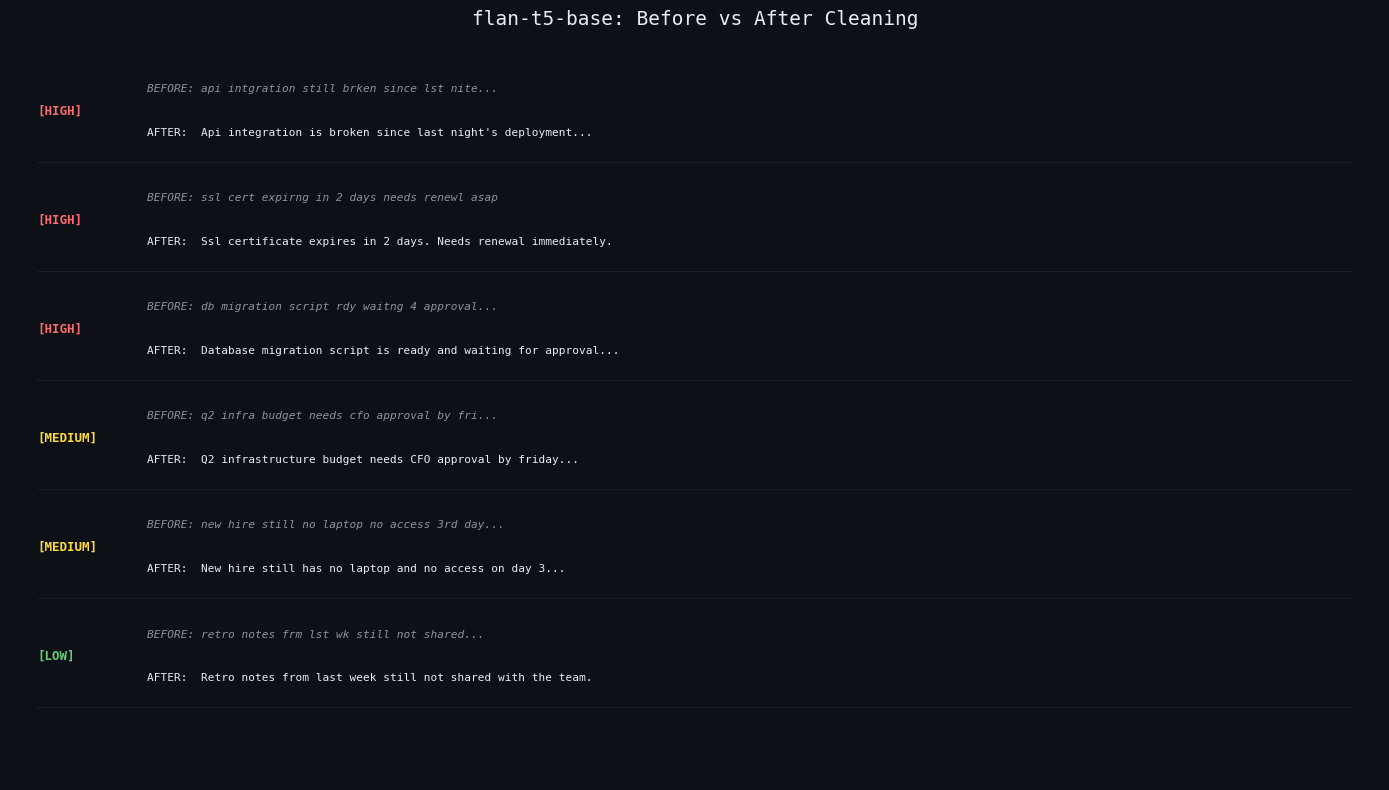

Saved: assets/viz_inference.png


In [16]:
# Fix axhline error - remove transform parameter
fig, ax = plt.subplots(figsize=(14, 8))
fig.patch.set_facecolor('#0d1117')
ax.set_facecolor('#0d1117')
ax.axis('off')

ax.set_title('flan-t5-base: Before vs After Cleaning', color='#e6edf3', fontsize=14, pad=20)

pairs = [
    ('api intgration still brken since lst nite...', 'Api integration is broken since last night\'s deployment...', 'HIGH'),
    ('ssl cert expirng in 2 days needs renewl asap', 'Ssl certificate expires in 2 days. Needs renewal immediately.', 'HIGH'),
    ('db migration script rdy waitng 4 approval...', 'Database migration script is ready and waiting for approval...', 'HIGH'),
    ('q2 infra budget needs cfo approval by fri...', 'Q2 infrastructure budget needs CFO approval by friday...', 'MEDIUM'),
    ('new hire still no laptop no access 3rd day...', 'New hire still has no laptop and no access on day 3...', 'MEDIUM'),
    ('retro notes frm lst wk still not shared...', 'Retro notes from last week still not shared with the team.', 'LOW'),
]

priority_colors = {'HIGH': '#ff6b6b', 'MEDIUM': '#ffd93d', 'LOW': '#6bcb77'}

for i, (before, after, priority) in enumerate(pairs):
    y = 0.92 - i * 0.15
    color = priority_colors[priority]
    ax.text(0.02, y, f'[{priority}]', transform=ax.transAxes,
            color=color, fontsize=9, fontweight='bold', va='center')
    ax.text(0.10, y + 0.03, f'BEFORE: {before}', transform=ax.transAxes,
            color='#8b949e', fontsize=8, va='center', style='italic')
    ax.text(0.10, y - 0.03, f'AFTER:  {after}', transform=ax.transAxes,
            color='#e6edf3', fontsize=8, va='center')
    # Fixed: removed transform parameter
    ax.plot([0.02, 0.98], [y - 0.07, y - 0.07], color='#21262d',
            linewidth=0.5, transform=ax.transAxes, clip_on=False)

plt.tight_layout()
plt.savefig('assets/viz_inference.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: assets/viz_inference.png')

## 6. Model Performance Summary

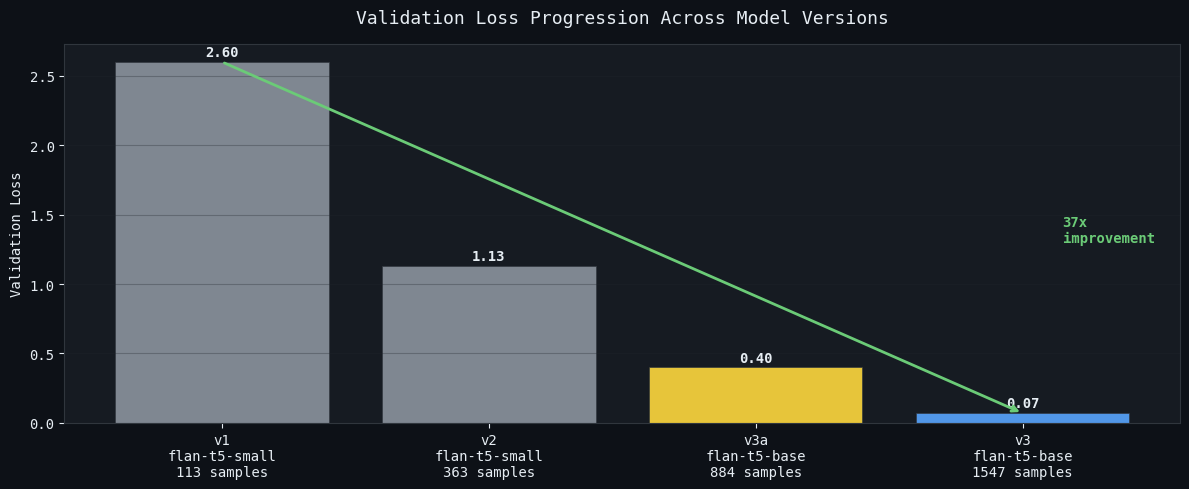

Saved: assets/viz_summary.png

 All visualizations complete!


In [18]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0d1117')

metrics = {
    'Val Loss\n(lower=better)': [2.60, 1.13, 0.40, 0.07],
    'Train Samples\n(hundreds)': [1.13, 3.63, 8.84, 12.37],
}

versions = ['v1\nflan-t5-small\n113 samples', 'v2\nflan-t5-small\n363 samples',
            'v3a\nflan-t5-base\n884 samples', 'v3\nflan-t5-base\n1547 samples']
val_losses = [2.60, 1.13, 0.40, 0.07]
colors = ['#8b949e', '#8b949e', '#ffd93d', '#58a6ff']

bars = ax.bar(versions, val_losses, color=colors, alpha=0.9, edgecolor='#30363d', linewidth=0.5)
ax.set_title('Validation Loss Progression Across Model Versions', color='#e6edf3', pad=15, fontsize=13)
ax.set_ylabel('Validation Loss', color='#e6edf3')
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, val_losses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', va='bottom', color='#e6edf3', fontweight='bold')

# Improvement annotation
ax.annotate('', xy=(3, 0.07), xytext=(0, 2.60),
            arrowprops=dict(arrowstyle='->', color='#6bcb77', lw=2))
ax.text(3.15, 1.3, '37x\nimprovement', color='#6bcb77', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('assets/viz_summary.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved: assets/viz_summary.png')
print('\n All visualizations complete!')